# 04 — Time-Series Stability and Final Short List

We have a pruned, multivariate-stable set (from notebook 03).  Now we stress-test those factors through time with **rolling-window multivariate regressions**, then combine the across-portfolios score and the across-time score into one final ranking.

The final short list (≈4–6 factors) is the set that scores well on **both** dimensions.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

DATA = Path('..').resolve() / 'data'
assets  = pd.read_csv(DATA / 'assets_excess.csv',  index_col=0, parse_dates=True)
factors = pd.read_csv(DATA / 'factors_excess.csv', index_col=0, parse_dates=True)
reps    = pd.read_csv(DATA / 'factor_cluster_reps.csv')
mvscore = pd.read_csv(DATA / 'mv_factor_scores.csv',  index_col=0)

pruned_cols = reps['factor'].tolist()
print(f'Using {len(pruned_cols)} pruned factors from notebook 03:', pruned_cols)

Using 12 pruned factors from notebook 03: ['HF FOF Div', 'MSCI Canada', 'EM Bond', 'High Yield', 'MSCI Japan', 'Commodities', 'US Dollar', 'TIPs', 'Global AGG', 'US Tbill 1-3yr', 'US Muni', 'Gold']


## 4.1 — Rolling multivariate regression (36-month window)

For each asset (and EWP) we walk a 36-month window across 2004–2013 and re-estimate the pruned multivariate.  For each (factor, portfolio, window) we keep β and t-stat.

In [2]:
WIN = 36

def rolling_betas(y, X, win=WIN):
    idx = X.index
    out = []
    for end in range(win, len(idx)+1):
        s, e = end-win, end
        ys, Xs_ = y.iloc[s:e], sm.add_constant(X.iloc[s:e])
        m = sm.OLS(ys, Xs_).fit()
        for f in X.columns:
            out.append({
                'window_end' : idx[e-1],
                'factor'     : f,
                'beta'       : m.params[f],
                't'          : m.tvalues[f],
            })
    return pd.DataFrame(out)

roll_frames = {a: rolling_betas(assets[a], factors[pruned_cols]) for a in assets.columns}
roll_long = pd.concat([df.assign(portfolio=a) for a, df in roll_frames.items()], ignore_index=True)
print('Rolling frame shape:', roll_long.shape)
roll_long.head()

Rolling frame shape: (6120, 5)


,window_end,factor,beta,t,portfolio
0,2006-12-29,HF FOF Div,0.059189,0.783289,Asset 1
1,2006-12-29,MSCI Canada,-0.002354,-0.120067,Asset 1
2,2006-12-29,EM Bond,0.137265,2.548118,Asset 1
3,2006-12-29,High Yield,-0.030630,-0.404436,Asset 1
4,2006-12-29,MSCI Japan,-0.005456,-0.298864,Asset 1


## 4.2 — Plot rolling β per factor (all portfolios overlaid)

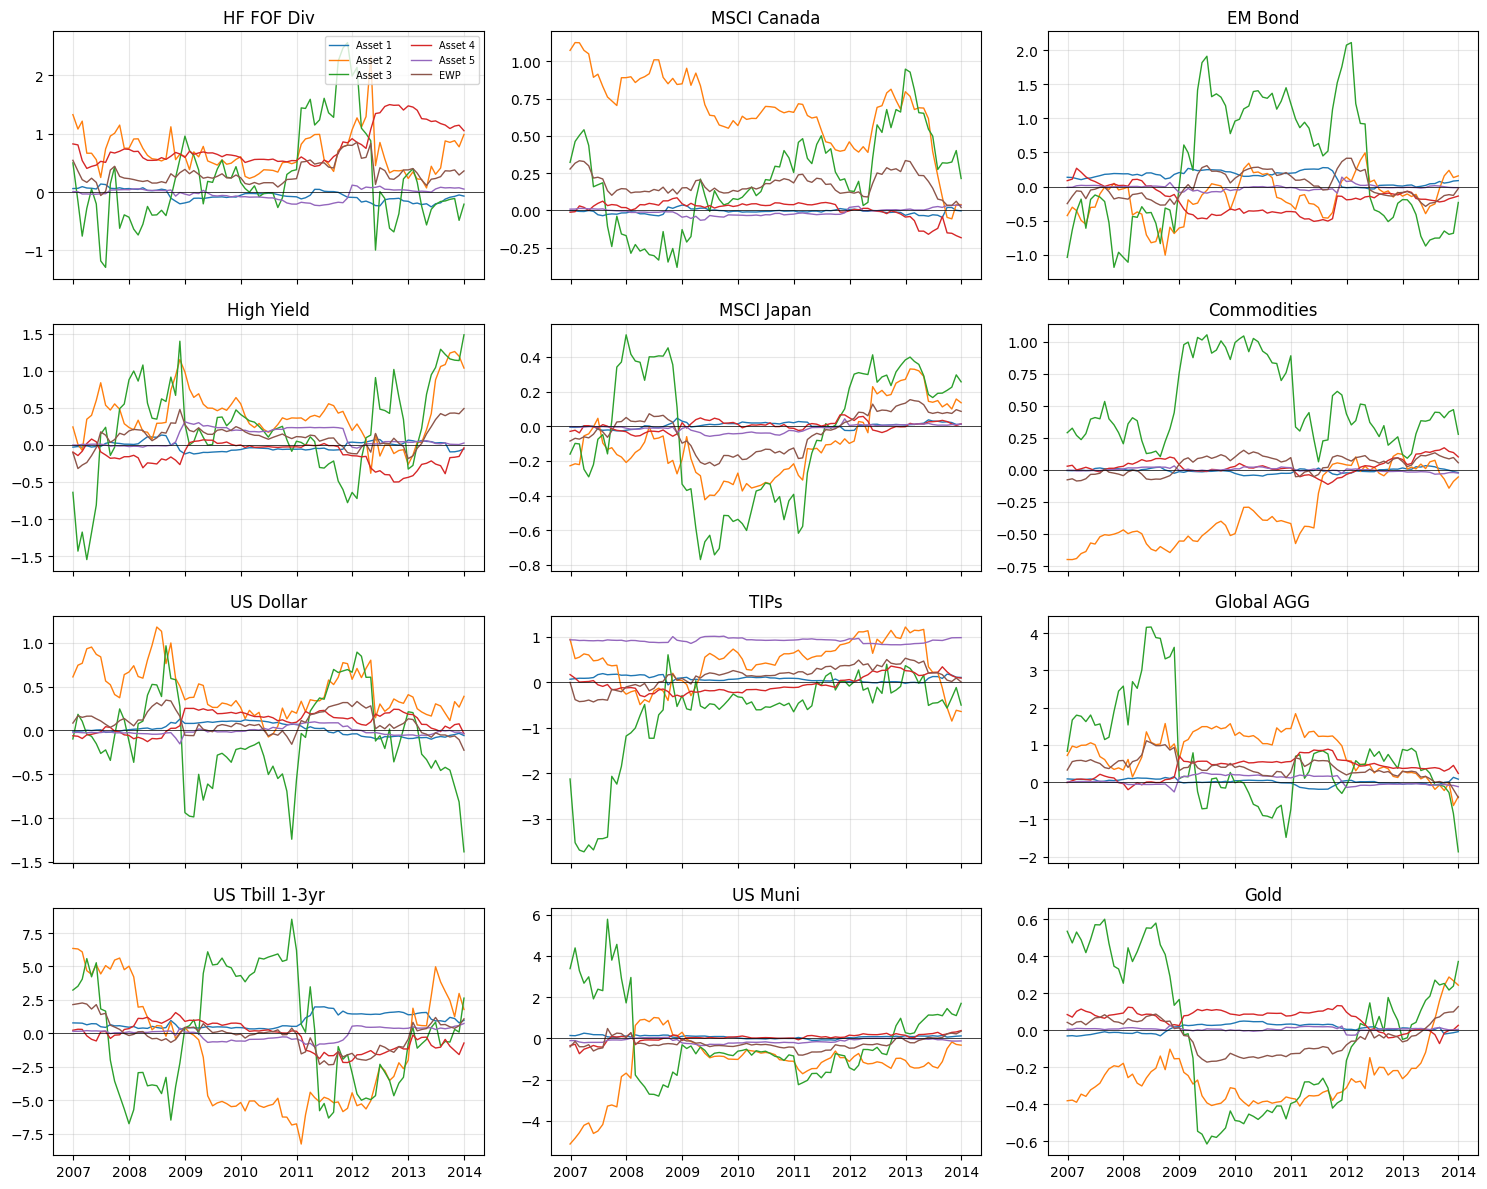

In [3]:
n = len(pruned_cols)
cols = 3; rows = int(np.ceil(n/cols))
fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows), sharex=True)
axes = axes.ravel()
for i, f in enumerate(pruned_cols):
    ax = axes[i]
    sub = roll_long[roll_long['factor'] == f]
    for a in assets.columns:
        s = sub[sub['portfolio'] == a].set_index('window_end')['beta']
        ax.plot(s.index, s.values, label=a, lw=1)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(f)
    ax.grid(alpha=0.3)
for j in range(i+1, len(axes)): axes[j].axis('off')
axes[0].legend(loc='upper right', fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

## 4.3 — Time-stability score per factor

For each factor we collect β across all rolling windows and all portfolios and compute:
- `beta_std_ts` — std of β across time and portfolios (lower is more stable)
- `sign_flip_rate` — share of consecutive windows where β changes sign *within the same portfolio* (lower is better)
- `tstat_hit_rate_ts` — fraction of (portfolio, window) pairs with |t|>1.65
- `median_beta_ts` — central tendency over time

In [4]:
def flip_rate(series):
    s = np.sign(series.values)
    if len(s) < 2: return np.nan
    return float((s[1:] != s[:-1]).mean())

ts_rows = []
for f in pruned_cols:
    sub = roll_long[roll_long['factor'] == f]
    flips = sub.groupby('portfolio')['beta'].apply(flip_rate).mean()
    ts_rows.append({
        'factor'           : f,
        'median_beta_ts'   : sub['beta'].median(),
        'beta_std_ts'      : sub['beta'].std(ddof=1),
        'sign_flip_rate'   : flips,
        'tstat_hit_rate_ts': float((sub['t'].abs() > 1.65).mean()),
    })
ts_scores = pd.DataFrame(ts_rows).set_index('factor')
ts_scores

,median_beta_ts,beta_std_ts,sign_flip_rate,tstat_hit_rate_ts
factor,,,,
HF FOF Div,0.228962,0.500526,0.059524,0.254902
MSCI Canada,0.038536,0.291118,0.043651,0.323529
EM Bond,-0.012900,0.435481,0.075397,0.209804
High Yield,0.040814,0.347907,0.093254,0.190196
MSCI Japan,-0.002250,0.183188,0.083333,0.107843
Commodities,0.006918,0.292328,0.089286,0.217647
US Dollar,0.057950,0.294840,0.081349,0.150980
TIPs,0.105571,0.694758,0.075397,0.303922
Global AGG,0.224002,0.673288,0.063492,0.272549


## 4.4 — Combine into final ranking

We rank on four sub-scores, all oriented so larger=better, then average.  The top ~4–6 is the final short list.

- `rank_mv_hits`       — higher = significant in more portfolios (from notebook 03)
- `rank_mv_signcon`    — higher = sign stable across portfolios
- `rank_ts_low_std`    — higher = low rolling-β std (stable in time)
- `rank_ts_low_flip`   — higher = few sign flips
- `rank_ts_hit`        — higher = high fraction of significant rolling windows

In [5]:
comb = mvscore.join(ts_scores, how='inner')
comb.index.name = 'factor'

# rank 1 = worst, N = best  (pandas rank ascending by default → lower value = lower rank)
comb['rank_mv_hits']     = comb['mv_hits_95'].rank()
comb['rank_mv_signcon']  = comb['mv_sign_consistency'].rank()
comb['rank_ts_low_std']  = comb['beta_std_ts'].rank(ascending=False)     # low std = high rank
comb['rank_ts_low_flip'] = comb['sign_flip_rate'].rank(ascending=False)  # low flips = high rank
comb['rank_ts_hit']      = comb['tstat_hit_rate_ts'].rank()

comb['final_score'] = comb[[
    'rank_mv_hits','rank_mv_signcon','rank_ts_low_std','rank_ts_low_flip','rank_ts_hit'
]].mean(axis=1)

final = comb.sort_values('final_score', ascending=False)
final

,mv_hits_95,mv_hits_90,mv_sign_consistency,mv_beta_mean,mv_beta_std,median_beta_ts,beta_std_ts,sign_flip_rate,tstat_hit_rate_ts,rank_mv_hits,rank_mv_signcon,rank_ts_low_std,rank_ts_low_flip,rank_ts_hit,final_score
factor,,,,,,,,,,,,,,,
MSCI Canada,2,2,0.666667,0.167711,0.242299,0.038536,0.291118,0.043651,0.323529,6.5,11.5,10.0,12.0,11.0,10.2
Gold,2,2,0.333333,-0.017375,0.086050,0.005110,0.200808,0.061508,0.415686,6.5,6.0,11.0,9.0,12.0,8.9
Global AGG,3,3,0.666667,0.277330,0.264043,0.224002,0.673288,0.063492,0.272549,10.5,11.5,4.0,8.0,9.0,8.6
HF FOF Div,2,4,0.333333,0.309086,0.310508,0.228962,0.500526,0.059524,0.254902,6.5,6.0,5.0,10.0,8.0,7.1
Commodities,3,3,0.333333,0.055760,0.291619,0.006918,0.292328,0.089286,0.217647,10.5,6.0,9.0,2.0,6.0,6.7
TIPs,2,4,0.333333,0.176182,0.402874,0.105571,0.694758,0.075397,0.303922,6.5,6.0,3.0,5.5,10.0,6.2
High Yield,4,5,0.333333,0.145871,0.243401,0.040814,0.347907,0.093254,0.190196,12.0,6.0,7.0,1.0,4.0,6.0
EM Bond,2,2,0.333333,-0.043611,0.125308,-0.012900,0.435481,0.075397,0.209804,6.5,6.0,6.0,5.5,5.0,5.8
US Muni,2,2,0.333333,-0.226376,0.339624,-0.093311,1.029740,0.055556,0.180392,6.5,6.0,2.0,11.0,3.0,5.7


## 4.5 — Pick the final short list

Rule of thumb: take the top ~6, then apply one qualitative check — the short list should span distinct economic buckets (rates, credit, equity beta, FX/commodity, alt).  If two finalists sit in the same bucket, drop the one with the lower `final_score`.  The notebook flags this; the user makes the final call.

In [6]:
TOP_N = 6
candidates = final.head(TOP_N).index.tolist()
print('Raw top-6 by final_score:', candidates)

# Attach their cluster IDs so we can spot same-bucket duplicates
bucket_map = pd.read_csv(DATA / 'factor_clusters.csv').set_index('factor')['cluster']
short = final.head(TOP_N).assign(cluster=[bucket_map[f] for f in candidates])
short[['final_score','cluster','mv_hits_95','mv_sign_consistency','beta_std_ts','sign_flip_rate','tstat_hit_rate_ts']]

Raw top-6 by final_score: ['MSCI Canada', 'Gold', 'Global AGG', 'HF FOF Div', 'Commodities', 'TIPs']


,final_score,cluster,mv_hits_95,mv_sign_consistency,beta_std_ts,sign_flip_rate,tstat_hit_rate_ts
factor,,,,,,,
MSCI Canada,10.2,2,2,0.666667,0.291118,0.043651,0.323529
Gold,8.9,12,2,0.333333,0.200808,0.061508,0.415686
Global AGG,8.6,9,3,0.666667,0.673288,0.063492,0.272549
HF FOF Div,7.1,1,2,0.333333,0.500526,0.059524,0.254902
Commodities,6.7,6,3,0.333333,0.292328,0.089286,0.217647
TIPs,6.2,8,2,0.333333,0.694758,0.075397,0.303922


In [7]:
# Drop duplicates within a cluster, keeping the highest final_score
dedup = (short.rename_axis('factor').reset_index()
              .sort_values('final_score', ascending=False)
              .drop_duplicates(subset='cluster'))
final_list = dedup['factor'].tolist()
print('\n=== FINAL FACTOR SHORT LIST ===')
for f in final_list:
    row = comb.loc[f]
    print(f'  {f:25s} | score={row["final_score"]:.2f} | '
          f'mv_hits={int(row["mv_hits_95"])}/6 | '
          f'β_std_ts={row["beta_std_ts"]:.2f} | '
          f'flip_rate={row["sign_flip_rate"]:.2f}')


=== FINAL FACTOR SHORT LIST ===
  MSCI Canada               | score=10.20 | mv_hits=2/6 | β_std_ts=0.29 | flip_rate=0.04
  Gold                      | score=8.90 | mv_hits=2/6 | β_std_ts=0.20 | flip_rate=0.06
  Global AGG                | score=8.60 | mv_hits=3/6 | β_std_ts=0.67 | flip_rate=0.06
  HF FOF Div                | score=7.10 | mv_hits=2/6 | β_std_ts=0.50 | flip_rate=0.06
  Commodities               | score=6.70 | mv_hits=3/6 | β_std_ts=0.29 | flip_rate=0.09
  TIPs                      | score=6.20 | mv_hits=2/6 | β_std_ts=0.69 | flip_rate=0.08


## 4.6 — Sanity: multivariate on the final list only

In [8]:
X = factors[final_list]
rows = []
for a in assets.columns:
    m = sm.OLS(assets[a], sm.add_constant(X)).fit()
    rows.append({'portfolio': a, 'R2': m.rsquared, 'adjR2': m.rsquared_adj})
pd.DataFrame(rows).set_index('portfolio')

,R2,adjR2
portfolio,,
Asset 1,0.662237,0.644303
Asset 2,0.648850,0.630205
Asset 3,0.553839,0.530149
Asset 4,0.517631,0.492018
Asset 5,0.953090,0.950599
EWP,0.757320,0.744435


In [9]:
# Save outputs
roll_long.to_csv(DATA / 'rolling_betas.csv', index=False)
ts_scores.to_csv(DATA / 'ts_factor_scores.csv')
comb.to_csv(DATA / 'combined_factor_ranking.csv')
pd.Series(final_list, name='factor').to_csv(DATA / 'final_factor_shortlist.csv', index=False)
print('saved final shortlist to', DATA / 'final_factor_shortlist.csv')

saved final shortlist to /sessions/brave-sharp-curie/mnt/Portfolio Management/PM Final Project/PM/data/final_factor_shortlist.csv


## How to read the result

The five numbers we are ranking on line up with the two goals:

| Goal | Sub-scores used |
| ---- | ---------------- |
| Stable **across portfolios** | `mv_hits_95` (significant on most assets), `mv_sign_consistency` (sign agrees on most assets) |
| Stable **across time** | `beta_std_ts` (low rolling-β dispersion), `sign_flip_rate` (few sign flips), `tstat_hit_rate_ts` (significant in most rolling windows) |

By averaging the ranks we reward factors that do well on **both** — we explicitly don't want a factor that has a huge R² on one asset but swings from +β to -β through time, and we don't want a factor that is stable but only matters for one asset.  That combination is what the slide deck calls 'fewer factors that are stable across time and across portfolios — a major win'.